<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pandas.core import frame
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
housing_raw="https://raw.githubusercontent.com/ageron/handson-ml/master/"
housing=pd.read_csv(housing_raw+"datasets/housing/housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


total_bedroom =20433 out of 20640(missing 207) also ocean_proxity is object type.We will use Imputer(for total bedrooms) and ordinalEncoder(for ocean proximity)

In [ ]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Higher std deviation --->median_housing_value,households,total_rooms,population

In [ ]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


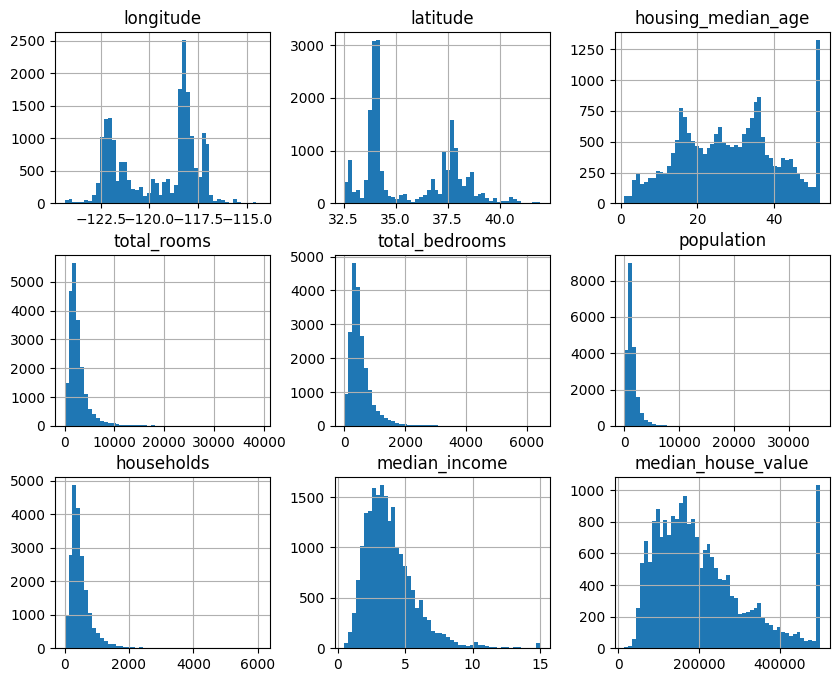

In [ ]:
housing.hist(bins=50,figsize=(10,8))
plt.show()

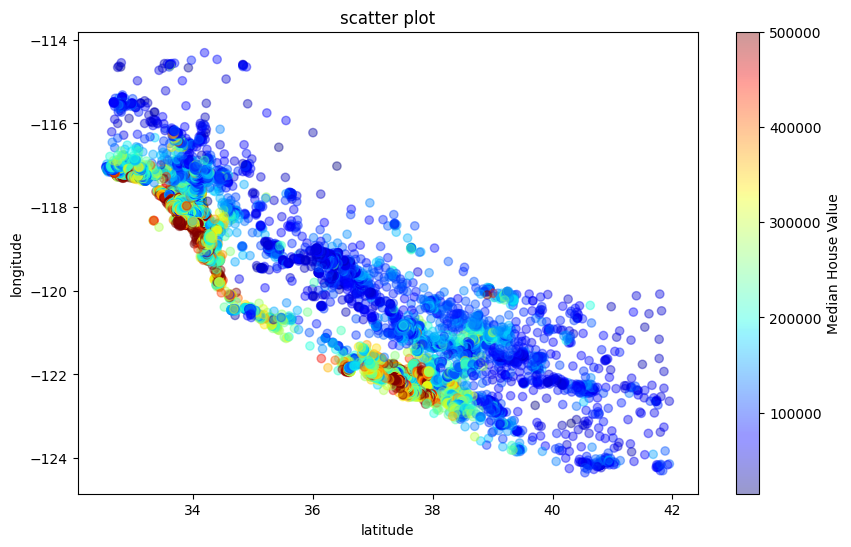

In [ ]:
from matplotlib import colorbar
plt.figure(figsize=(10,6))
scatter_plot = plt.scatter(housing['latitude'],housing['longitude'],alpha=0.4,c=housing['median_house_value'],cmap=plt.get_cmap('jet'))
plt.colorbar(scatter_plot, label='Median House Value') # Added label to the colorbar
plt.xlabel('latitude')
plt.ylabel('longitude')
plt.title('scatter plot')
plt.show()

from scatter plot we can see that house which is closer to sea have high house value(red and yellow color)

## `Ocean-proximity` categorical data handling

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
ocean_proximity=housing.drop('ocean_proximity',axis=1)
ordinal=OrdinalEncoder()
ocean_ordinal_encoded=ordinal.fit_transform(housing[['ocean_proximity']])
ocean_ordinal_encoded



array([[3.],
       [3.],
       [3.],
       ...,
       [1.],
       [1.],
       [1.]])

In [ ]:
ocean_ordinal_encoded=pd.DataFrame(ocean_ordinal_encoded,columns=['ocean_proximity'],index=housing.index)
ocean_ordinal_encoded.head()

,ocean_proximity
0,3.0
1,3.0
2,3.0
3,3.0
4,3.0


In [ ]:
housing_final=pd.concat([ocean_proximity,ocean_ordinal_encoded],axis=1)
housing_final.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3.0


As you can see from the output:

*   `housing['ocean_proximity']` is a `pandas.Series` and has a shape of `(20640,)`, indicating a 1-dimensional structure.
*   `housing[['ocean_proximity']]` is a `pandas.DataFrame` and has a shape of `(20640, 1)`, indicating a 2-dimensional structure with one column.

This distinction is important, especially when using functions or methods that expect a DataFrame (e.g., `fit_transform` in some scikit-learn transformers) or a Series.

Now ocean_proximity is converted to numerical data

## `total_bedrooms` missing value handling

### Handling Missing Values in `total_bedrooms`

As noted earlier, the `total_bedrooms` column has 207 missing values. We will use `sklearn.impute.SimpleImputer` to fill these missing values with the median of the column. The median is chosen because it is more robust to outliers than the mean.

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_final)
X = imputer.transform(housing_final)
housing_final = pd.DataFrame(X, columns=housing_final.columns, index=housing_final.index)
housing_final.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3.0


In [ ]:
for col_name in housing_final.columns:
    print(f"variance of {col_name} is {np.var(housing_final[col_name])}")


variance of longitude is 4.013944883584757
variance of latitude is 4.562071602892503
variance of housing_median_age is 158.3885861703583
variance of total_rooms is 4759214.51266799
variance of total_bedrooms is 175881.02548628923
variance of population is 1282408.3220366791
variance of households is 146168.95772780414
variance of median_income is 3.60914768969746
variance of median_house_value is 13315503000.817923
variance of ocean_proximity is 2.018184076133487


We can see that the data point is not standarized so we will try standardized the data(i.e variance to 1)

## `standardizing data`
### Feature Scaling

Machine Learning algorithms don't perform well when the input numerical attributes have very different scales. For instance, the `total_rooms` and `median_income` are on different scales. To address this, we need to apply **Feature Scaling**.

Two common ways to get all attributes to have the same scale are Min-Max scaling (Normalization) and Standardization. Here, we will use **Standardization** (using `StandardScaler`), which is less affected by outliers than Min-Max scaling.

**Before standardizing data we will drop the label(median_house_value) from dataset,labels is not standarized**

In [ ]:
labels=housing_final['median_house_value'].copy()
features=housing_final.drop("median_house_value",axis=1)

In [ ]:
from sklearn.preprocessing import  StandardScaler
scaler=StandardScaler()
transformation=scaler.fit_transform(features)
housing_prepared=pd.DataFrame(transformation,columns=features.columns,index=features.index)
housing_prepared.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,1.291089
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.291089
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.291089
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.291089
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.291089


In [ ]:
for col_name in housing_prepared.columns:
    print(f"variance of {col_name} is {np.var(housing_prepared[col_name])}")


variance of longitude is 0.9999999999999907
variance of latitude is 0.9999999999999811
variance of housing_median_age is 1.0000000000000362
variance of total_rooms is 0.9999999999999964
variance of total_bedrooms is 1.000000000000005
variance of population is 0.9999999999999967
variance of households is 0.9999999999999848
variance of median_income is 0.9999999999999964
variance of ocean_proximity is 0.9999999999997499


We can see than variance of column's is ~1.(data is scaled)

In [ ]:
housing_prepared.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,-8.526513e-15,-1.079584e-15,5.508083e-18,3.201573e-17,-9.363741e-17,-1.101617e-17,6.885104e-17,6.609700e-17,-5.508083e-18
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-2.385992e+00,-1.447568e+00,-2.196180e+00,-1.207283e+00,-1.277688e+00,-1.256123e+00,-1.303984e+00,-1.774299e+00,-8.206532e-01
25%,-1.113209e+00,-7.967887e-01,-8.453931e-01,-5.445698e-01,-5.718868e-01,-5.638089e-01,-5.742294e-01,-6.881186e-01,-8.206532e-01
50%,5.389137e-01,-6.422871e-01,2.864572e-02,-2.332104e-01,-2.428309e-01,-2.291318e-01,-2.368162e-01,-1.767951e-01,-1.167392e-01
75%,7.784964e-01,9.729566e-01,6.643103e-01,2.348028e-01,2.537334e-01,2.644949e-01,2.758427e-01,4.593063e-01,-1.167392e-01
max,2.625280e+00,2.958068e+00,1.856182e+00,1.681558e+01,1.408779e+01,3.025033e+01,1.460152e+01,5.858286e+00,1.995003e+00


## Correlation Matrix

In [ ]:
corr=housing_prepared.corr()
corr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.289779
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,0.200974
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.112468
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,-0.015693
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,-0.014631
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.070282
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,-0.018186
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,-0.014957
ocean_proximity,-0.289779,0.200974,0.112468,-0.015693,-0.014631,-0.070282,-0.018186,-0.014957,1.000000


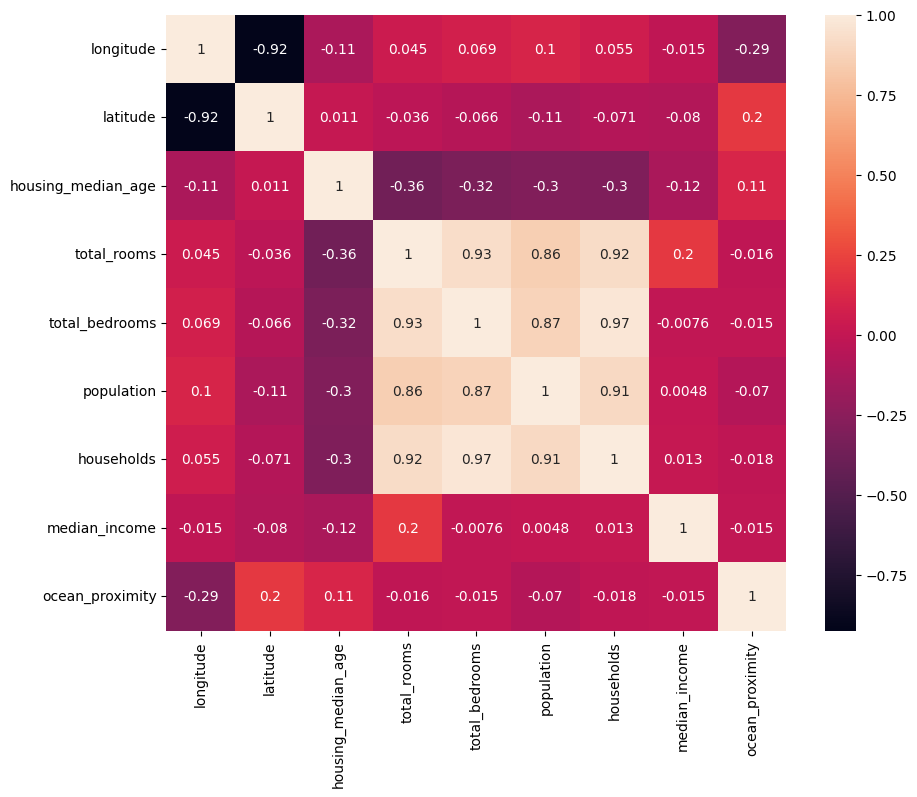

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.show()

**From heatmap,we observe that**

*total_rooms have strong +ve relation with total_bedroom,population,households(i.e  these feature have +ve relation with each other)*





## Performing Linear Regression

Before doing Linear Regression ,we need to split data into Train and Test sets

In [ ]:
from sklearn.model_selection import train_test_split

# Using train_test_split for regression tasks (without stratification for continuous target)
X_train, X_test, y_train, y_test = train_test_split(housing_prepared, labels, test_size=0.2, random_state=42, shuffle=True)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(16512, 9) (16512,)
(4128, 9) (4128,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [ ]:
LR=LinearRegression()
LR.fit(X_train,y_train)

LinearRegression()

Generating Prediction Test for both Train and Test

In [ ]:
LR_Train_Pred=LR.predict(X_train)
LR_Test_Pred=LR.predict(X_test)

RMSE and R_ score

$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( Y -\hat{Y} \right)^2}$

$\text{RMSE} = \sqrt{MSE}$

*   y :  actual label
*   $\hat{y}$ :  predicted label



In [ ]:
from sklearn.metrics import  root_mean_squared_error
print("rmse X_train:",root_mean_squared_error(y_train,LR_Train_Pred))
print("rmse X_test:",root_mean_squared_error(y_test,LR_Test_Pred))

rmse X_train: 69361.0714290645
rmse X_test: 71147.87146118376


since rsme(test) > rsme(train) , so case of `overfitting`

In [ ]:
print("score on X_train :",LR.score(X_train,y_train))
print("score on X_test :",LR.score(X_test,y_test))

score on X_train : 0.6401079709888613
score on X_test : 0.6137068886499535


### Root Mean Squared Error (RMSE)

Root Mean Squared Error (RMSE) is a commonly used metric for evaluating the performance of regression models. It is the square root of the average of the squared differences between predicted values and actual values. RMSE is particularly useful because:

*   It measure how far off an actual value is from the model's prediction for that value or,
*   It indicates how much error you can expect from a prediction


A lower RMSE generally indicates a better-fitting model.

*   RMSE of test > RMSE of train => OVER-FITTING of the data.
*   RMSE of test < RMSE of train => UNDER-FITTING of the data.

## `Decision Tree Regression`

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_regressor=DecisionTreeRegressor()
dt_regressor.fit(X_train,y_train)

DecisionTreeRegressor()

Prediction on Train and Test

In [ ]:
dt_train_predict=dt_regressor.predict(X_train)
dt_test_predict=dt_regressor.predict(X_test)

In [ ]:
print("rsme on train :",root_mean_squared_error(y_train,dt_train_predict))
print("rsme on test :",root_mean_squared_error(y_test,dt_test_predict))

rsme on train : 0.0
rsme on test : 67777.71578670474


rsme(test) >> rsme(tran) ,overfit

In [ ]:
print("score on train :",dt_regressor.score(X_train,y_train))
print("score on Test :",dt_regressor.score(X_test,y_test))

score on train : 1.0
score on Test : 0.649436257417124


## `Cross validation Score` - Evaluation tool
*we split the data into k equal parts (commonly 5 or 10), train the model on k-1 parts, and test it on the remaining part*


*   **Traditional one-time "train-test" splits can lead to biased results if the split happens to be particularly "easy" or "hard". CV averages results across multiple splits to provide a more robust performance estimate.**



compairing `Linear and decision tree`
But how can say which algorithm is performing well on dataset,the answer is Cross validation score by looking their mean and std.(yes we can choose algorithm which has lower rmse but cvs split data int k unbiased parts)

## **Evaluating `Linear Regression` Performance using CVS**

In [ ]:
from sklearn.model_selection import cross_val_score
cs_lr=cross_val_score(LR,X_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [ ]:
rmse_score=np.sqrt(-cs_lr)
rmse_score

array([66187.62479242, 72779.35713344, 68950.17710356, 67634.12212475,
       70452.68132171, 66516.76635312, 66535.02116758, 71001.14354709,
       74319.03994135, 70669.19262425])

In [ ]:
print('Mean : ',rmse_score.mean()) # actually rsme as it already calculated sqrt then mean
print('std : ',rmse_score.std())

Mean :  69504.5126109282
std :  2663.673929328215


## **Evaluating `Decision Tree Regressor` Performance  using CVS**

In [ ]:
cs_ds=cross_val_score(dt_regressor,X_train,y_train,scoring="neg_mean_squared_error",cv=10)
rmse_score_dt=np.sqrt(-cs_ds)
rmse_score_dt

array([69820.19986886, 70264.68478292, 66957.63526356, 69887.50251938,
       70423.53820656, 67852.80481175, 69793.13407274, 69900.17685302,
       72022.10047568, 72887.69024593])

In [ ]:
print("Mean : ",rmse_score_dt.mean())
print("std : ",rmse_score_dt.std())

Mean :  69980.94671004021
std :  1632.1038559824701


we can see that mean for LinearRegression <  than Mean for Decision tree.So Linear Regression performing better than decison tree but std for decision tree is more consistent than linear Regression across different folds.

K-fold cross validation is sampling as well as evaluation tool.Before doing K-fold cross_val we need to do initial data split(train and Test)

```
# from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Initialize your model
model = LinearRegression()

# 2. Define your K-Fold strategy (e.g., 5 folds)
# shuffle=True is highly recommended to ensure data randomness
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Calculate the scores
# For regression, 'neg_mean_squared_error' or 'r2' are common. For classification, 'accuracy'.
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# 4. Display results
print(f"Scores for each fold: {scores}")
print(f"Mean CV Score (R²): {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")
```



## `Random Forest  Regressor`
* **A Random Forest is a machine learning algorithm that combines multiple decision Trees to generate more accurate and stable predictions. Instead of relying on a single model, it aggregates the outputs of several trees, reducing overfitting and improving overall reliability**

In [ ]:
from sklearn.ensemble import  RandomForestRegressor
RF=RandomForestRegressor()
RF.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
RF_Test_predict=RF.predict(X_test)
RF_Train_predict=RF.predict(X_train)

In [ ]:
print("rmse on Train",root_mean_squared_error(y_train,RF_Train_predict))
print("rmse on Test",root_mean_squared_error(y_test,RF_Test_predict))

rmse on Train 18392.08133334878
rmse on Test 49936.32752922345


## Evaluating `Random Forest Regressor` performance using cvs

In [ ]:
RF_cvs=cross_val_score(RF,X_train,y_train,scoring='neg_mean_squared_error',cv=10)
RF_cvs_score=np.sqrt(-RF_cvs)
RF_cvs_score

array([48314.00487937, 51051.48566962, 48567.48861598, 50486.39110878,
       51048.30623919, 47600.79671697, 46920.18996936, 51230.1691468 ,
       50993.60284158, 50031.81530457])

In [ ]:
print("Mean : ",RF_cvs_score.mean()) # actually rsme as it already calculated sqrt then mean
print("std : ",RF_cvs_score.std())

Mean :  49624.425049221434
std :  1538.4481966941032


So Random Forest is performing better than Linear regression,but rsme on validation set(approx 49683) which is much greater than rsme on train(18319) so overfitting.

**we can verify it using score**

In [ ]:
print("Train score :",RF.score(X_train,y_train))
print("Test score :",RF.score(X_test,y_test))

Train score : 0.9746952297105661
Test score : 0.8097054546700869


## `Train,Test,Validation set`
* `Train set` - During Model Traing
* `Validation set` - During model tuning and selection.
* `Test set` - At the very end of the project, We only touch the test set after ensuring that our model is performing well on the validation data.It is like final exam paper.


## `Fine Tune Model`

In [ ]:
from sklearn.model_selection import  GridSearchCV
param_grid = [
{'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
{'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             scoring='neg_mean_squared_error')

In [ ]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

In [ ]:
cvres=grid_search.cv_results_
for mean,params in zip(cvres['mean_test_score'],cvres['params']):
    print(np.sqrt(-mean),params)

61341.116474976385 {'max_features': 2, 'n_estimators': 3}
53905.61005682122 {'max_features': 2, 'n_estimators': 10}
51599.4252334758 {'max_features': 2, 'n_estimators': 30}
57240.408339803915 {'max_features': 4, 'n_estimators': 3}
52234.93253453904 {'max_features': 4, 'n_estimators': 10}
49647.3155750336 {'max_features': 4, 'n_estimators': 30}
58012.46243417316 {'max_features': 6, 'n_estimators': 3}
51477.656435651785 {'max_features': 6, 'n_estimators': 10}
49774.63898318373 {'max_features': 6, 'n_estimators': 30}
58325.73836344315 {'max_features': 8, 'n_estimators': 3}
52245.849579283924 {'max_features': 8, 'n_estimators': 10}
50259.83152517597 {'max_features': 8, 'n_estimators': 30}
59267.86314709356 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
52489.72097934963 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
58432.625195803725 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
51459.24128863274 {'bootstrap': False, 'max_features': 3, 'n_estimators':

## Evaluating on X_test

In [ ]:
final_model=grid_search.best_estimator_
rsme_test_grid=final_model.predict(X_test)
print("rsme :",root_mean_squared_error(y_test,rsme_test_grid))

rsme : 49457.46171369781


Now we can see that our rmse is approx 49457.